# Compare public-emulator C(ℓ)

- Compare weak-lensing C(ℓ) derived from non-linear total matter P(k).
- Each target emulator supplies P_total(k,z).
- DarkEmulator2 and target P(k) are mapped to the same k grid and Limber integration.

## Common settings

- `sample_params_for()` samples the DQ2-target overlap range.
- `flags` disable target-unsupported dimensions.
- `valid_*()` applies target-specific cuts.
- `pk_to_cl()` converts P(k,z) to C(ℓ) with the shared Limber setup.

In [1]:
from pathlib import Path
import os
import random
import subprocess
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import InterpolatedUnivariateSpline as ius
from tqdm import tqdm

import dark_emulator2.derived as dv
from dark_emulator2 import DarkEmulator2

MTU_DIR = Path("~/software/src/python/CosmicEmu").expanduser()
# MTU_DIR = Path("./CosmicEmu")

In [ ]:
N_COSMO = 10
SEED = 1234

ZLIST = np.linspace(0.0, 1.0, 61)
RAW_KLIST = np.logspace(-3, 1, 301)
CL_KLIST = np.logspace(-2, 3, 401)
LLIST = np.logspace(1, 4, 101)

# None means a single source plane at ZLIST[-1].
SRC_DIST = None
PSHOT_FOR_EXTRAP = 0.3

In [ ]:
def sample_params_for(preset, flags, valid=None, n=N_COSMO, seed=SEED, max_try=100000):
    random.seed(seed)
    np.random.seed(seed)
    emu = DarkEmulator2()
    range_dict = emu.param.get_preset_range_dict_pair("preset_de2", preset)
    params = []
    ntry = 0

    with tqdm(total=n, desc=f"sample {preset}") as pbar:
        while len(params) < n:
            ntry += 1
            if ntry > max_try:
                raise RuntimeError(f"Only {len(params)} valid cosmologies were found for {preset} after {max_try} tries.")

            p = emu.param.rand_param_cosmology(range_dict=range_dict, **flags)
            if not flags.get("nu", True):
                p["Mnu"] = 0.0
                p["Omega_nu"] = 0.0
            else:
                p["Omega_nu"] = p["Mnu"] / (93.14 * p["h0"]**2)

            emu.param.clear_As(p)
            emu.param.clear_lnAs(p)
            p["As"] = emu.get_As(p)
            p["dist"] = emu.get_power_distance(p)

            if "As" in range_dict and not (range_dict["As"][0] <= p["As"] <= range_dict["As"][1]):
                continue
            if valid is not None and not valid(p, emu):
                continue

            params.append(p)
            pbar.update(1)
            pbar.set_postfix(tries=ntry)

    return sorted(params, key=lambda q: q["dist"])

In [ ]:
def extrap_pk_to_cl_grid(k, orig_k, pk, pshot=PSHOT_FOR_EXTRAP):
    scalar_input = False
    if pk.ndim == 1:
        pk = pk[np.newaxis]
        scalar_input = True

    pk = np.array([ius(np.log(orig_k), _pk)(np.log(k)) for _pk in pk])

    kmin, kmax = min(orig_k), max(orig_k)
    support_kmax = np.where(k < kmax)[0][-1]
    support_kmin = np.where(k > kmin)[0][0]

    cutoff_factor = 10
    logk = np.log10(k)
    logpk = np.log10(np.abs(pk))
    cutoff_pk = np.log10(cutoff_factor * pshot)
    pk_extrap = []
    for ilogpk in logpk:
        hits = np.flatnonzero(ilogpk[support_kmin:] < cutoff_pk)
        cutoff_idx = support_kmin + (hits[0] if hits.size else support_kmax)
        if k[cutoff_idx] > kmax:
            cutoff_idx = support_kmax
        pk_tmp = ius(logk[support_kmin:cutoff_idx], ilogpk[support_kmin:cutoff_idx], k=1)(logk)
        pk_extrap.append(10.0**pk_tmp)

    pk_extrap = np.array(pk_extrap)
    if scalar_input:
        pk_extrap = np.squeeze(pk_extrap)
    return pk_extrap


def run_de2_pk(params, zlist=ZLIST, klist=RAW_KLIST):
    emu = DarkEmulator2()
    pk = []
    for p in tqdm(params, desc="DE2 P(k)"):
        k, y = emu.get_pk_total(p, zred=zlist, klist=klist, method="emulator")
        pk.append(y)
    return k, np.asarray(pk)


def pk_to_cl(params, k, pk, zlist=ZLIST, cl_klist=CL_KLIST, llist=LLIST, src_dist=SRC_DIST, label="P(k) -> C(ℓ)"):
    k = np.asarray(k)
    pk = np.asarray(pk)
    cls = []
    for i, (p, y) in enumerate(tqdm(list(zip(params, pk)), desc=label)):
        k_i = k if k.ndim == 1 else k[i]
        pk_i = extrap_pk_to_cl_grid(cl_klist, k_i, np.asarray(y))
        ell, cl = dv.pk2cl_limber_src_dist(
            p, pk=pk_i, klist=cl_klist, zlist=zlist,
            llist=llist, nsz=src_dist, modified=True,
        )
        cls.append(cl)
    return ell, np.asarray(cls)


def run_de2_cl(params):
    k, pk = run_de2_pk(params)
    ell, cl = pk_to_cl(params, k, pk, label="DE2 C(ℓ)")
    return k, pk, ell, cl


def compare_target_cl(label, params, run_pk):
    t0 = time.perf_counter()
    k_de2, pk_de2, ell_de2, cl_de2 = run_de2_cl(params)
    de2_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    k_tgt, pk_tgt = run_pk(params)
    ell_tgt, cl_tgt = pk_to_cl(params, k_tgt, pk_tgt, label=f"{label} C(ℓ)")
    target_time = time.perf_counter() - t0

    result = dict(label=label, params=params, ell_de2=ell_de2, cl_de2=cl_de2, ell_tgt=ell_tgt, cl_tgt=cl_tgt)
    print(f"DE2: {de2_time:.2f} sec")
    print(f"{label}: {target_time:.2f} sec")
    return result

In [5]:
def plot_cl_comparison(result):
    params = result["params"]
    ell_de2 = np.asarray(result["ell_de2"])
    ell_tgt = np.asarray(result["ell_tgt"])
    cl_de2 = np.asarray(result["cl_de2"])
    cl_tgt = np.asarray(result["cl_tgt"])
    label = result["label"]

    colors = plt.cm.jet(np.linspace(0.05, 0.95, len(params)))
    fig, axes = plt.subplots(2, 1, figsize=(6.2, 6.2), sharex=True, height_ratios=[2, 1])
    ax0, ax1 = axes

    for i, color in enumerate(colors):
        ok_d = np.isfinite(cl_de2[i]) & (cl_de2[i] > 0)
        ok_t = np.isfinite(cl_tgt[i]) & (cl_tgt[i] > 0)
        de2_on_tgt = np.exp(np.interp(np.log(ell_tgt[ok_t]), np.log(ell_de2[ok_d]), np.log(cl_de2[i][ok_d])))

        ax0.loglog(ell_de2[ok_d], ell_de2[ok_d]**2 * cl_de2[i][ok_d] / (2.0 * np.pi), "--", color=color, lw=0.9, alpha=0.65)
        ax0.loglog(ell_tgt[ok_t], ell_tgt[ok_t]**2 * cl_tgt[i][ok_t] / (2.0 * np.pi), "-", color=color, lw=0.9, alpha=0.75)
        ax1.semilogx(ell_tgt[ok_t], cl_tgt[i][ok_t] / de2_on_tgt, "-", color=color, lw=0.9, alpha=0.8)

    ax0.plot([], [], "k--", label="DarkEmulator2")
    ax0.plot([], [], "k-", label=label)
    ax0.set_ylabel(r"$\ell^2 C_\ell / 2\pi$")
    ax0.legend(fontsize="large")
    ax0.grid(True, which="both", alpha=0.3)

    ax1.axhline(1.0, color="0.2", lw=0.8)
    ax1.axhline(0.95, color="0.4", lw=0.7, ls=":")
    ax1.axhline(1.05, color="0.4", lw=0.7, ls=":")
    ax1.set_ylim(0.75, 1.25)
    ax1.set_xlabel(r"$\ell$")
    ax1.set_ylabel(f"{label} / DE2")
    ax1.grid(True, which="both", alpha=0.3)

    fig.suptitle(rf"source plane $z_s={ZLIST[-1]:.1f}$")
    fig.tight_layout()
    plt.show()

## EuclidEmulator2

In [6]:
import euclidemu2 as ee2


def to_ee2(p):
    return dict(As=p["As"], ns=p["ns"], Omb=p["omega_b"] / p["h0"]**2, Omm=p["Omega_m"], h=p["h0"], mnu=p["Mnu"], w0=p["w0"], wa=p["wa"])


def valid_ee2(p, emu):
    return 0.04 <= to_ee2(p)["Omb"] <= 0.06


ee2_params = sample_params_for("preset_ee2", flags=dict(nu=True, w0=True, wa=True, K=False), valid=valid_ee2)
print(f"{len(ee2_params)} cosmologies selected for DE2 vs EuclidEmulator2.")

sample preset_ee2: 100%|██████████████████████████████████████████████████████| 10/10 [00:07<00:00,  1.27it/s, tries=56]

10 cosmologies selected for DE2 vs EuclidEmulator2.


In [7]:
def run_ee2_pk(params, zlist=ZLIST):
    emu = ee2.PyEuclidEmulator()
    pk = []
    for p in tqdm(params, desc="EE2 P(k)"):
        k, pnl, _, _ = emu.get_pnonlin(to_ee2(p), zlist)
        pk.append(np.asarray(list(pnl.values())))
    return k, np.asarray(pk)


ee2_result = compare_target_cl("EuclidEmulator2", ee2_params, run_ee2_pk)

EuclidEmulator2 C(ℓ): 100%|█████████████████████████████████████████████████████████████| 10/10 [00:04<00:00,  2.08it/s]

DE2: 21.70 sec
EuclidEmulator2: 76.63 sec


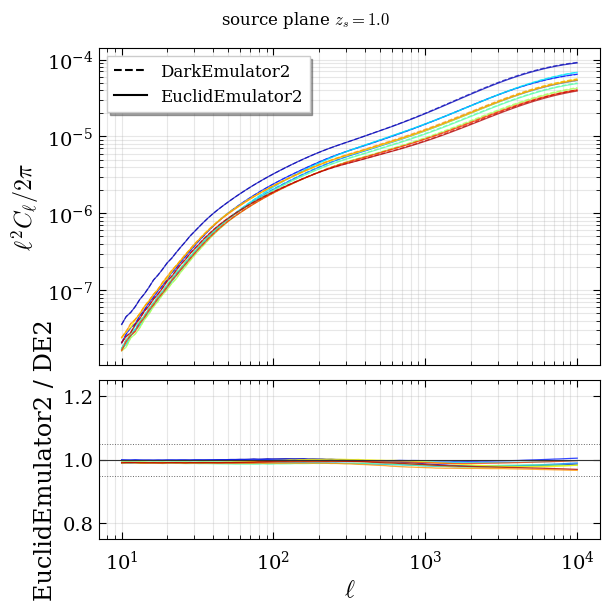

In [8]:
plot_cl_comparison(ee2_result)

## BACCOemu

In [9]:
import baccoemu as bce

bacco_sigma8_emu = bce.Matter_powerspectrum(verbose=False)


def to_bacco(p):
    return dict(A_s=p["As"], ns=p["ns"], omega_baryon=p["omega_b"] / p["h0"]**2, omega_cold=p["Omega_m"] - p["Omega_nu"], hubble=p["h0"], neutrino_mass=p["Mnu"], w0=p["w0"], wa=p["wa"])


def valid_bacco(p, emu):
    b = to_bacco(p)
    if not (0.04 <= b["omega_baryon"] <= 0.06 and 0.23 <= b["omega_cold"] <= 0.40):
        return False
    return 0.73 <= bacco_sigma8_emu.get_sigma8(**b) <= 0.9


bacco_params = sample_params_for("preset_bacco", flags=dict(nu=True, w0=True, wa=True, K=False), valid=valid_bacco)
print(f"{len(bacco_params)} cosmologies selected for DE2 vs BACCOemu.")

sample preset_bacco: 100%|███████████████████████████████████████████████████| 10/10 [00:41<00:00,  4.17s/it, tries=133]

10 cosmologies selected for DE2 vs BACCOemu.


In [10]:
def run_bacco_pk(params, zlist=ZLIST, klist=RAW_KLIST):
    emu = bce.Matter_powerspectrum(verbose=False)
    k = emu.emulator["nonlinear"]["k"]
    pk = []
    for p in tqdm(params, desc="BACCO P(k)"):
        bcep = to_bacco(p)
        pk.append([emu.get_nonlinear_pk(k=k, cold=False, expfactor=1.0 / (1.0 + z), **bcep)[1] for z in zlist])
    return k, np.asarray(pk)


bacco_result = compare_target_cl("BACCOemu", bacco_params, run_bacco_pk)

BACCOemu C(ℓ): 100%|████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  7.34it/s]

DE2: 8.61 sec
BACCOemu: 17.96 sec


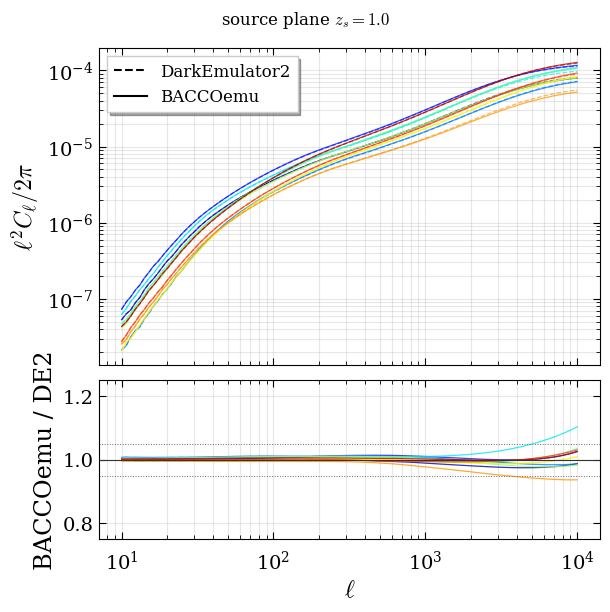

In [11]:
plot_cl_comparison(bacco_result)

## Aemulus

In [12]:
from aemulus_heft.heft_emu import HEFTEmulator
from aemulus_heft.utils import lpt_spectra


def to_aemulus(p):
    return dict(omega_b=p["omega_b"], omega_cdm=p["omega_cdm"], As=p["As"], h0=p["h0"], w0=p["w0"], ns=p["ns"], Mnu=p["Mnu"])


aemulus_params = sample_params_for("preset_aemulus", flags=dict(nu=True, w0=True, wa=False, K=False))
print(f"{len(aemulus_params)} cosmologies selected for DE2 vs Aemulus.")

sample preset_aemulus: 100%|██████████████████████████████████████████████████| 10/10 [00:07<00:00,  1.25it/s, tries=11]

10 cosmologies selected for DE2 vs Aemulus.


In [13]:
def run_aemulus_pk(params, zlist=ZLIST, klist=RAW_KLIST):
    emu = HEFTEmulator()
    k = klist[klist < 4.0]
    pk = []
    for p in tqdm(params, desc="Aemulus P(k)"):
        a = to_aemulus(p)
        aemup = [a["omega_b"], a["omega_cdm"], a["w0"], a["ns"], a["As"] * 1e9, 100 * a["h0"], min(0.49, a["Mnu"])]
        row = []
        for z in zlist:
            spec_lpt, sigma8z = lpt_spectra(k, z, aemup)
            row.append(emu.predict(k, np.asarray(aemup + [sigma8z]), spec_lpt)[0])
        pk.append(row)
    return k, np.asarray(pk)


aemulus_result = compare_target_cl("Aemulus", aemulus_params, run_aemulus_pk)

Aemulus C(ℓ): 100%|█████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 13.01it/s]


DE2: 54.71 sec
Aemulus: 1555.53 sec


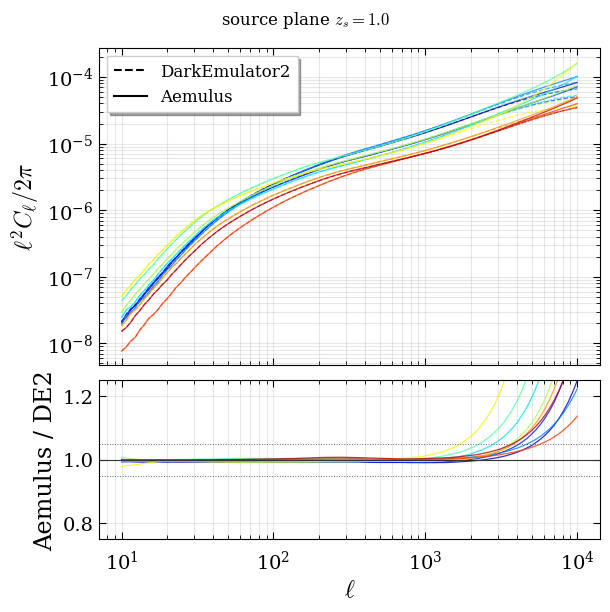

In [14]:
plot_cl_comparison(aemulus_result)

## Mira-Titan IV

In [15]:
def to_mtu(p):
    wsum = -(p["w0"] + p["wa"])
    return dict(omega_m=p["Omega_m"] * p["h0"]**2, sigma8=p["sigma8"], omega_b=p["omega_b"], ns=p["ns"], h=p["h0"], omega_nu=p["Omega_nu"] * p["h0"]**2, w0=p["w0"], wa=p["wa"], w0wa4=wsum**0.25 if wsum > 0 else np.nan)


def valid_mtu(p, emu):
    m = to_mtu(p)
    return 0.120 <= m["omega_m"] <= 0.155 and 0.0 <= m["omega_nu"] <= 0.01 and 0.3 <= m["w0wa4"] <= 1.29


mtu_params = sample_params_for("preset_mtu", flags=dict(nu=True, w0=True, wa=True, K=False), valid=valid_mtu)
print(f"{len(mtu_params)} cosmologies selected for DE2 vs Mira-Titan IV.")

sample preset_mtu: 100%|██████████████████████████████████████████████████████| 10/10 [00:37<00:00,  3.79s/it, tries=36]

10 cosmologies selected for DE2 vs Mira-Titan IV.


In [16]:
def run_mtu_pk(params, zlist=ZLIST, klist=RAW_KLIST):
    run_dir = Path.cwd()
    os.chdir(MTU_DIR)
    try:
        lines = []
        for p in params:
            m = to_mtu(p)
            sigma8 = min(max(m["sigma8"], 0.700001), 0.899999)
            for z in zlist:
                lines.append(f"{m['omega_m']:.6f} {m['omega_b']:.6f} {sigma8:.6f} {m['h']:.6f} {m['ns']:.6f} {m['w0']:.6f} {m['wa']:.6f} {m['omega_nu']:.6f} {z:.6f}")
        Path("xstar.dat").write_text("\n".join(lines) + "\n")
        subprocess.call("./2022-Mira-Titan-IV/P_tot/emu.exe")
        all_k, all_pk = [], []
        for ip, p in enumerate(tqdm(params, desc="Mira-Titan P(k)")):
            row = []
            for iz in range(len(zlist)):
                k, y = np.loadtxt(f"EMU{ip * len(zlist) + iz:d}.txt", unpack=True)
                Path(f"EMU{ip * len(zlist) + iz:d}.txt").unlink()
                row.append(y * p["h0"]**3)
            all_k.append(k / p["h0"])
            all_pk.append(row)
        return np.asarray(all_k), np.asarray(all_pk)
    finally:
        os.chdir(run_dir)


mtu_result = compare_target_cl("Mira-Titan IV", mtu_params, run_mtu_pk)

Mira-Titan IV C(ℓ): 100%|███████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 12.03it/s]

DE2: 4.37 sec
Mira-Titan IV: 2.93 sec


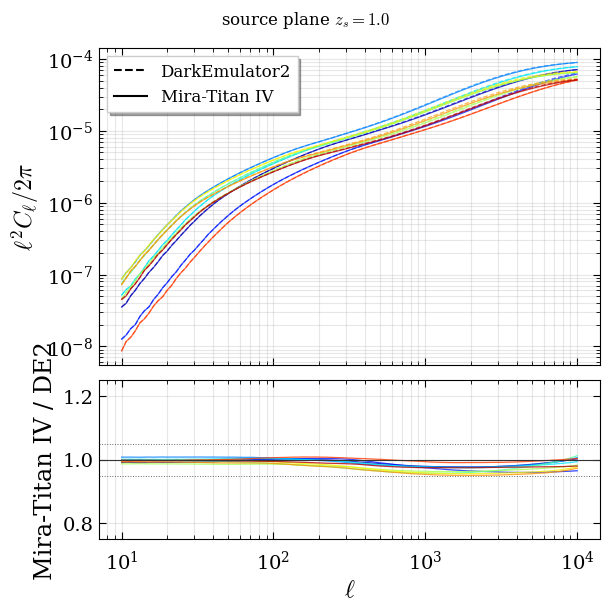

In [17]:
plot_cl_comparison(mtu_result)

## GokuNEmu

In [18]:
from gokunemu import MatterPowerEmulator


def to_goku(p):
    return dict(Omega_m=p["Omega_m"], Omega_b=p["omega_b"] / p["h0"]**2, h0=p["h0"], As=p["As"], ns=p["ns"], Mnu=p["Mnu"], w0=p["w0"], wa=p["wa"], Neff=3.044, alpha_s=0.0)


def valid_goku(p, emu):
    return 0.040 <= to_goku(p)["Omega_b"] <= 0.055


goku_params = sample_params_for("preset_goku", flags=dict(nu=True, w0=True, wa=True, K=False), valid=valid_goku)
print(f"{len(goku_params)} cosmologies selected for DE2 vs GokuNEmu.")

sample preset_goku: 100%|█████████████████████████████████████████████████████| 10/10 [00:02<00:00,  4.06it/s, tries=50]

10 cosmologies selected for DE2 vs GokuNEmu.


In [19]:
def run_goku_pk(params, zlist=ZLIST, klist=RAW_KLIST):
    emu = MatterPowerEmulator()
    order = ["Omega_m", "Omega_b", "h0", "As", "ns", "w0", "wa", "Mnu", "Neff", "alpha_s"]
    cosmo = np.asarray([[to_goku(p)[key] for key in order] for p in params])
    k, pk = emu.get_matter_power(cosmo, redshifts=zlist)
    return k, np.asarray(pk)


goku_result = compare_target_cl("GokuNEmu", goku_params, run_goku_pk)

GokuNEmu C(ℓ): 100%|████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 15.20it/s]

DE2: 3.90 sec
GokuNEmu: 1.02 sec


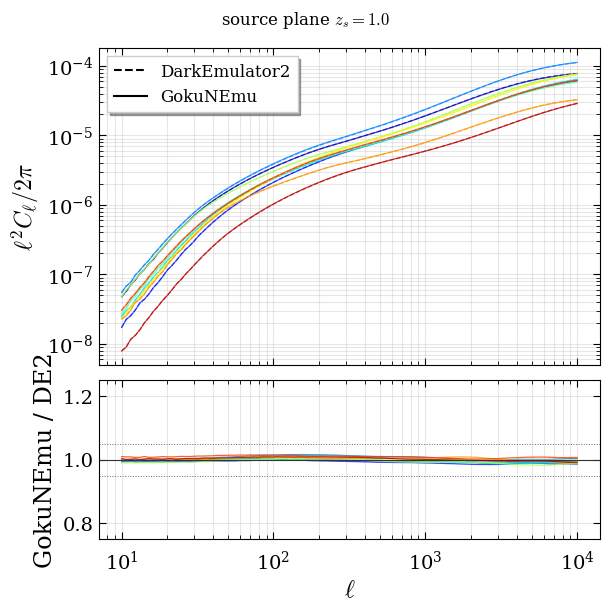

In [20]:
plot_cl_comparison(goku_result)

## Aletheia

In [ ]:
from aletheiacosmo import AletheiaEmu
from aletheiacosmo.cosmology import Cosmology as AletheiaCosmo

aletheia_check = AletheiaEmu()


def to_aletheia(p):
    h = p["h0"]
    omega_k = p["Omega_k"] * h**2
    omega_de = h**2 - p["omega_cdm"] - p["omega_b"] - omega_k
    return dict(A_s=p["As"], n_s=p["ns"], omega_b=p["omega_b"], omega_c=p["omega_cdm"], h=h, omega_nu=0.0, w_0=p["w0"], w_a=p["wa"], omega_k=omega_k, omega_de=omega_de)


def valid_aletheia(p, emu):
    a = to_aletheia(p)
    if not (0.3000 * 0.925 < a["omega_de"] < 0.3000 * 1.125):
        return False
    if emu.param.check_planck_sigma(p) > 5.0:
        return False
    cosmo = AletheiaCosmo(a)
    try:
        aletheia_check._validate_params(a, cosmo.get_sigma12(0.0))
        aletheia_check._validate_params(a, cosmo.get_sigma12(3.0))
    except ValueError:
        return False
    return True


aletheia_params = sample_params_for("preset_aletheia", flags=dict(nu=False, w0=True, wa=True, K=False), valid=valid_aletheia)
print(f"{len(aletheia_params)} cosmologies selected for DE2 vs Aletheia.")

In [ ]:
def run_aletheia_pk(params, zlist=ZLIST, klist=RAW_KLIST):
    emu = AletheiaEmu()
    k_nl = np.logspace(-2.22, np.log10(2.0), 200)
    all_k, all_pk = [], []
    for p in tqdm(params, desc="Aletheia P(k)"):
        values = to_aletheia(p)
        all_k.append(k_nl / p["h0"])
        all_pk.append([emu.get_pnl(k_nl, values, z) * p["h0"]**3 for z in zlist])
    return np.asarray(all_k), np.asarray(all_pk)

aletheia_result = compare_target_cl("Aletheia", aletheia_params, run_aletheia_pk)

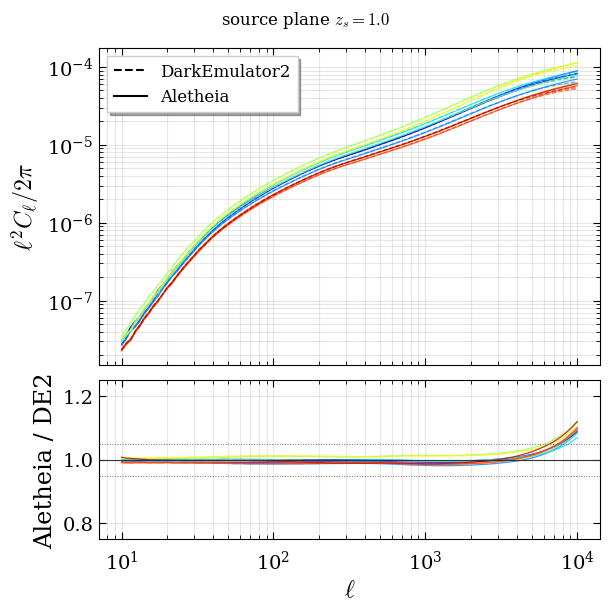

In [ ]:
plot_cl_comparison(aletheia_result)

## CSSTemu

In [24]:
from CEmulator.Emulator import Pkmm_CEmulator


# Use "single" to compare with the native CSSTemu training convention.
CSSTEMU_NEUTRINO_MASS_SPLIT = "degenerate"


def to_csstemu(p):
    Omegab = p["omega_b"] / p["h0"]**2
    Omeganu = p.get("Omega_nu", p["Mnu"] / (93.14 * p["h0"]**2))
    Omegac = p["Omega_m"] - Omeganu - Omegab
    return dict(Omegab=Omegab, Omegac=Omegac, H0=100.0 * p["h0"], As=p["As"], ns=p["ns"], w=p["w0"], wa=p["wa"], mnu=p["Mnu"])


def valid_csstemu(p, emu):
    c = to_csstemu(p)
    Omegacb = c["Omegab"] + c["Omegac"]
    return 0.04 <= c["Omegab"] <= 0.06 and 0.24 <= Omegacb <= 0.40 and c["Omegac"] > 0.0


csstemu_params = sample_params_for("preset_csstemu", flags=dict(nu=True, w0=True, wa=True, K=False), valid=valid_csstemu)
print(f"{len(csstemu_params)} cosmologies selected for DE2 vs CSSTemu.")

sample preset_csstemu: 100%|██████████████████████████████████████████████████| 10/10 [00:03<00:00,  3.06it/s, tries=52]

10 cosmologies selected for DE2 vs CSSTemu.


In [25]:
def run_csstemu_pk(params, zlist=ZLIST, klist=RAW_KLIST):
    emu = Pkmm_CEmulator(neutrino_mass_split=CSSTEMU_NEUTRINO_MASS_SPLIT)
    klist = np.asarray(klist)
    kmin = emu.Bkcb.klist[0]
    kmax = min(10.0, emu.Bkcb.klist[-1])
    k = klist[(kmin <= klist) & (klist <= kmax)]
    pk = []
    for p in tqdm(params, desc="CSSTemu P(k)"):
        emu.set_cosmos(**to_csstemu(p))
        pk.append(emu.get_pknl(z=zlist, k=k, Pcb=False, lintype="Emulator", nltype="hmcode2020"))
    return k, np.asarray(pk)


csstemu_result = compare_target_cl("CSSTemu", csstemu_params, run_csstemu_pk)

CSSTemu C(ℓ): 100%|█████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 12.40it/s]

DE2: 5.62 sec
CSSTemu: 8.83 sec


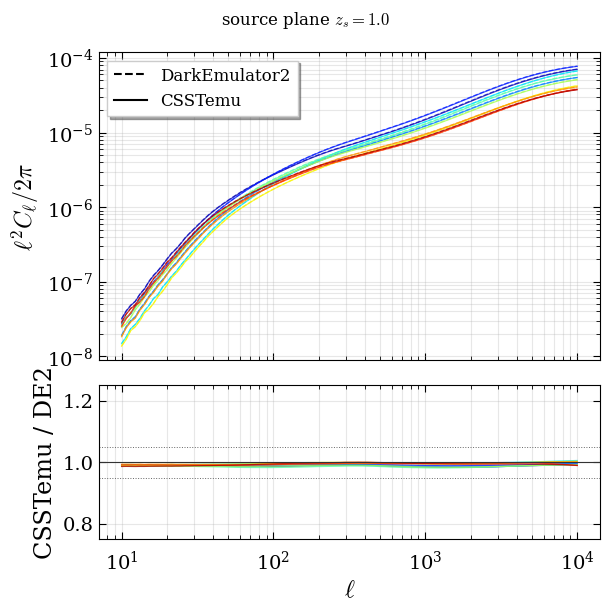

In [ ]:
plot_cl_comparison(csstemu_result)